# Bachelor Thesis

© 2026 Yvan Richard   
University of St. Gallen, Spring Term 2026

## Concentration of Buying versus Selling

---
## Foreword

In theory, attention-induced trading should predominantly affect purchase rather than sale decisions—retail investors can buy any stock that captures their attention but can only sell stocks that they own (unless they sell short, which is relatively uncommon among retail investors and not possible on the Robinhood platform). Hence, it is expected that attention-motivated trading is common among Robinhood users. To test this conjecture, I follow Barber et al. (2022).


## 1. Libraries & Data

I first load the relevant libraries and data.

In [3]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [2]:
# baseline trading sample
df = pd.read_csv("../../../data/processed/baseline_trading_sample.csv")

# parse dates
df["date"] = pd.to_datetime(df["date"])

# sort by date and ticker
df = df.sort_values(by=["date", "ticker"])

/var/folders/7v/_v_y1jpx0rl056gg5rkjsw4r0000gn/T/ipykernel_47637/2122537406.py:2: DtypeWarning: Columns (13) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../../../data/processed/baseline_trading_sample.csv")


## 2. Visual Evidence

In this section, I first replicate figure 2.

In [24]:
# ============================================================
# 1. PREPARE PANEL
# ============================================================

def prepare_panel(df: pd.DataFrame) -> pd.DataFrame:
    """
    Prepare the stock-day panel used for Figure 2.

    Required columns:
        - date
        - ticker
        - userchg   : Robinhood daily net user change
        - net_buys  : TAQ daily retail net buying

    Notes:
    - We keep the common stock-day sample where both RH and TAQ are observed.
    - We do NOT winsorize the net-flow variables here.
      Figure 2 is about concentration in actual net buying/selling, so clipping
      raw signed flows would mechanically distort both rankings and shares.
    """
    out = df.copy()
    out["date"] = pd.to_datetime(out["date"])

    out["rh_net"] = out["userchg"]
    out["taq_net"] = out["net_buys"]

    out = out.dropna(subset=["date", "ticker", "rh_net", "taq_net"]).copy()

    return out


# ============================================================
# 2. DAILY RANK-SHARE CONSTRUCTION FOR ONE SERIES
# ============================================================

def build_rank_shares(
    df: pd.DataFrame,
    value_col: str,
    side: str,
    top_n: int = 10
) -> pd.DataFrame:
    """
    Construct daily rank shares for one series (Robinhood or TAQ).

    Parameters
    ----------
    df : pd.DataFrame
        Stock-day panel.
    value_col : str
        Column containing signed net flow (e.g. 'rh_net' or 'taq_net').
    side : str
        Either 'buy' or 'sell'.
        - 'buy'  : use only positive net flows
        - 'sell' : use only negative net flows, converted to positive magnitudes
    top_n : int
        Number of ranks to retain.

    Returns
    -------
    pd.DataFrame with columns:
        - date
        - rank
        - share
    """
    assert side in {"buy", "sell"}, "side must be 'buy' or 'sell'"

    out_list = []

    for date, g in df.groupby("date", sort=True):
        tmp = g[["ticker", value_col]].copy()

        if side == "buy":
            tmp = tmp[tmp[value_col] > 0].copy()
            tmp["amount"] = tmp[value_col]
        else:
            tmp = tmp[tmp[value_col] < 0].copy()
            tmp["amount"] = -tmp[value_col]   # selling magnitude

        if tmp.empty:
            continue

        total_amount = tmp["amount"].sum()
        if total_amount <= 0:
            continue

        tmp = tmp.sort_values("amount", ascending=False).reset_index(drop=True)
        tmp["rank"] = np.arange(1, len(tmp) + 1)
        tmp["share"] = tmp["amount"] / total_amount

        tmp = tmp[tmp["rank"] <= top_n].copy()
        tmp["date"] = date

        out_list.append(tmp[["date", "rank", "share"]])

    if not out_list:
        return pd.DataFrame(columns=["date", "rank", "share"])

    return pd.concat(out_list, ignore_index=True)


# ============================================================
# 3. AGGREGATE ACROSS DAYS
# ============================================================

def summarize_rank_shares(rank_df: pd.DataFrame) -> pd.DataFrame:
    """
    Aggregate daily rank shares across days.

    Figure 2 reports mean daily percent of net buying/selling by rank,
    with 95% confidence intervals based on standard errors across days.
    """
    if rank_df.empty:
        return pd.DataFrame(columns=["rank", "mean", "se", "ci_low", "ci_high", "n_days"])

    out = (
        rank_df.groupby("rank")["share"]
        .agg(["mean", "std", "count"])
        .reset_index()
        .rename(columns={"count": "n_days"})
    )

    out["se"] = out["std"] / np.sqrt(out["n_days"])
    out["ci_low"] = out["mean"] - 1.96 * out["se"]
    out["ci_high"] = out["mean"] + 1.96 * out["se"]

    # convert to percentages for plotting
    for col in ["mean", "se", "ci_low", "ci_high"]:
        out[col] = 100 * out[col]

    return out[["rank", "mean", "se", "ci_low", "ci_high", "n_days"]]


# ============================================================
# 4. BUILD ALL FOUR SERIES NEEDED FOR FIGURE 2
# ============================================================

def build_figure2_data(df: pd.DataFrame, top_n: int = 10) -> dict:
    """
    Build summary data for:
        - Robinhood buying
        - TAQ buying
        - Robinhood selling
        - TAQ selling
    """
    panel = prepare_panel(df)

    rh_buy_daily = build_rank_shares(panel, value_col="rh_net", side="buy", top_n=top_n)
    taq_buy_daily = build_rank_shares(panel, value_col="taq_net", side="buy", top_n=top_n)
    rh_sell_daily = build_rank_shares(panel, value_col="rh_net", side="sell", top_n=top_n)
    taq_sell_daily = build_rank_shares(panel, value_col="taq_net", side="sell", top_n=top_n)

    rh_buy = summarize_rank_shares(rh_buy_daily)
    taq_buy = summarize_rank_shares(taq_buy_daily)
    rh_sell = summarize_rank_shares(rh_sell_daily)
    taq_sell = summarize_rank_shares(taq_sell_daily)

    return {
        "panel": panel,
        "rh_buy": rh_buy,
        "taq_buy": taq_buy,
        "rh_sell": rh_sell,
        "taq_sell": taq_sell,
    }


# ============================================================
# 5. PLOT FIGURE 2
# ============================================================

def plot_figure_2(
    rh_buy: pd.DataFrame,
    taq_buy: pd.DataFrame,
    rh_sell: pd.DataFrame,
    taq_sell: pd.DataFrame,
    figsize=(12, 5),
    savepath: str | None = None
) -> None:
    """
    Plot Figure 2 in a style close to Barber et al. (2022).

    Visual choices:
    - Robinhood bars: green fill
    - TAQ bars: white fill with black edge
    - grouped bars for each rank
    - 95% CI whiskers
    """

    fig, axes = plt.subplots(1, 2, figsize=figsize, sharey=True)

    bar_w = 0.36
    x = np.arange(1, 11)

    # ---------- Panel A: Buying ----------
    ax = axes[0]

    ax.bar(
        x - bar_w/2,
        rh_buy["mean"],
        width=bar_w,
        color="dodgerblue",
        edgecolor="black",
        linewidth=0.4,
        label="Robinhood"
    )
    ax.bar(
        x + bar_w/2,
        taq_buy["mean"],
        width=bar_w,
        color="coral",
        edgecolor="black",
        linewidth=0.8,
        label="TAQ Retail Trade"
    )

    ax.errorbar(
        x - bar_w/2,
        rh_buy["mean"],
        yerr=1.96 * rh_buy["se"],
        fmt="none",
        ecolor="black",
        elinewidth=0.7,
        capsize=2
    )
    ax.errorbar(
        x + bar_w/2,
        taq_buy["mean"],
        yerr=1.96 * taq_buy["se"],
        fmt="none",
        ecolor="black",
        elinewidth=0.7,
        capsize=2
    )

    ax.set_title("Panel A: Concentration of Buying", fontsize=12, family="Times New Roman")
    ax.set_xlabel("Rank of Net Buying")
    ax.set_ylabel("Percent of Net Buying")
    ax.set_xticks(x)
    ax.set_xlim(0.4, 10.6)
    ax.set_axisbelow(True)
    ax.grid(axis="y", alpha=0.7, color="skyblue", zorder=10)
    ax.legend(loc="lower center", bbox_to_anchor=(0.5, -0.28), ncol=2, frameon=True, fontsize=9)

    # ---------- Panel B: Selling ----------
    ax = axes[1]

    ax.bar(
        x - bar_w/2,
        rh_sell["mean"],
        width=bar_w,
        color="dodgerblue",
        edgecolor="black",
        linewidth=0.4,
        label="Robinhood"
    )
    ax.bar(
        x + bar_w/2,
        taq_sell["mean"],
        width=bar_w,
        color="coral",
        edgecolor="black",
        linewidth=0.8,
        label="TAQ Retail Trade"
    )

    ax.errorbar(
        x - bar_w/2,
        rh_sell["mean"],
        yerr=1.96 * rh_sell["se"],
        fmt="none",
        ecolor="black",
        elinewidth=0.7,
        capsize=2
    )
    ax.errorbar(
        x + bar_w/2,
        taq_sell["mean"],
        yerr=1.96 * taq_sell["se"],
        fmt="none",
        ecolor="black",
        elinewidth=0.7,
        capsize=2
    )

    ax.set_title("Panel B: Concentration of Selling", fontsize=12, family="Times New Roman")
    ax.set_xlabel("Rank of Net Selling")
    ax.set_ylabel("Proportion of Net Selling")
    ax.set_xticks(x)
    ax.set_xlim(0.4, 10.6)
    ax.set_axisbelow(True)
    ax.grid(axis="y", alpha=0.7, color="skyblue")
    ax.legend(loc="lower center", bbox_to_anchor=(0.5, -0.28), ncol=2, frameon=True, fontsize=9)

    # Style adjustments to look closer to the paper
    for ax in axes:
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    plt.tight_layout()

    if savepath is not None:
        plt.savefig(savepath, bbox_inches="tight")

    plt.show()


# ============================================================
# 6. ONE-STEP WRAPPER
# ============================================================

def replicate_figure_2(df: pd.DataFrame, savepath: str | None = None) -> dict:
    """
    Full pipeline to prepare data and plot Figure 2.
    """
    out = build_figure2_data(df, top_n=10)

    plot_figure_2(
        rh_buy=out["rh_buy"],
        taq_buy=out["taq_buy"],
        rh_sell=out["rh_sell"],
        taq_sell=out["taq_sell"],
        savepath=savepath
    )

    return out

In [13]:
out1 = build_figure2_data(df, top_n=10)

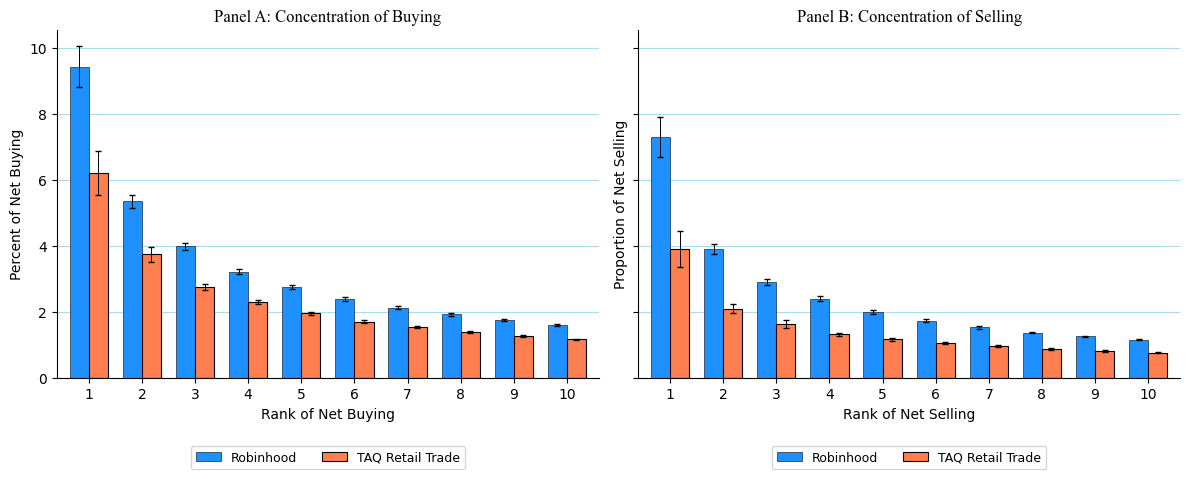

In [25]:
plot_figure_2(
    rh_buy=out1["rh_buy"],
    taq_buy=out1["taq_buy"],
    rh_sell=out1["rh_sell"],
    taq_sell=out1["taq_sell"],
    savepath="../../../figures/figure_2_concentration_buying_selling.pdf"
)

In [30]:
out1

{'panel':               date  users_close  users_start  users_last  intraday_userchg  \
 28178   2018-05-04        170.0        170.0       170.0               0.0   
 34241   2018-05-04        679.0        679.0       679.0               0.0   
 49910   2018-05-04       1916.0       1916.0      1916.0               0.0   
 88939   2018-05-04       3285.0       3285.0      3285.0               0.0   
 119253  2018-05-04        174.0        174.0       174.0               0.0   
 ...            ...          ...          ...         ...               ...   
 3839867 2020-08-11       6320.0       6323.0      6320.0              -3.0   
 3840197 2020-08-11       5543.0       5611.0      5541.0             -68.0   
 3840743 2020-08-11        674.0        675.0       674.0              -1.0   
 3841308 2020-08-11      31859.0      31920.0     31860.0             -61.0   
 3841681 2020-08-11       3150.0       3171.0      3150.0             -21.0   
 
         ticker   permno       ret    prc

## 3. Replication of Table III form Barber et al. (2022)

In [26]:
# ============================================================
# 7. DAILY CONCENTRATION STATISTICS FOR TABLE III
# ============================================================

def compute_daily_concentration_stats(
    df: pd.DataFrame,
    value_col: str,
    top_n: int = 10
) -> pd.DataFrame:
    """
    For one net-flow series (Robinhood or TAQ), compute daily:
        - HH_buy_bps
        - Top10_buy_pct
        - HH_sell_bps
        - Top10_sell_pct

    Parameters
    ----------
    df : pd.DataFrame
        Stock-day panel.
    value_col : str
        Signed net-flow column, e.g. 'rh_net' or 'taq_net'.
    top_n : int
        Number of top ranks used in Top10.

    Returns
    -------
    pd.DataFrame with one row per date.
    """

    out_rows = []

    for date, g in df.groupby("date", sort=True):
        row = {"date": date}

        # ------------------------------
        # BUY SIDE
        # ------------------------------
        buy = g.loc[g[value_col] > 0, ["ticker", value_col]].copy()
        if not buy.empty:
            buy["amount"] = buy[value_col]
            total_buy = buy["amount"].sum()

            if total_buy > 0:
                buy = buy.sort_values("amount", ascending=False).reset_index(drop=True)
                buy["rank"] = np.arange(1, len(buy) + 1)
                buy["share"] = buy["amount"] / total_buy

                # HH in basis points
                row["HH_buy_bps"] = 10000 * np.sum(np.square(buy["share"]))

                # Top10 share in percent
                row["Top10_buy_pct"] = 100 * buy.loc[buy["rank"] <= top_n, "share"].sum()
            else:
                row["HH_buy_bps"] = np.nan
                row["Top10_buy_pct"] = np.nan
        else:
            row["HH_buy_bps"] = np.nan
            row["Top10_buy_pct"] = np.nan

        # ------------------------------
        # SELL SIDE
        # ------------------------------
        sell = g.loc[g[value_col] < 0, ["ticker", value_col]].copy()
        if not sell.empty:
            sell["amount"] = -sell[value_col]   # positive selling magnitude
            total_sell = sell["amount"].sum()

            if total_sell > 0:
                sell = sell.sort_values("amount", ascending=False).reset_index(drop=True)
                sell["rank"] = np.arange(1, len(sell) + 1)
                sell["share"] = sell["amount"] / total_sell

                row["HH_sell_bps"] = 10000 * np.sum(np.square(sell["share"]))
                row["Top10_sell_pct"] = 100 * sell.loc[sell["rank"] <= top_n, "share"].sum()
            else:
                row["HH_sell_bps"] = np.nan
                row["Top10_sell_pct"] = np.nan
        else:
            row["HH_sell_bps"] = np.nan
            row["Top10_sell_pct"] = np.nan

        out_rows.append(row)

    return pd.DataFrame(out_rows).sort_values("date").reset_index(drop=True)


# ============================================================
# 8. HELPER FUNCTIONS FOR TABLE III
# ============================================================

def mean_se_t_p(x: pd.Series) -> tuple:
    """
    Return mean, standard error, t-stat, p-value for a daily series.
    """
    x = x.dropna()
    n = len(x)

    if n == 0:
        return np.nan, np.nan, np.nan, np.nan

    mean = x.mean()

    if n == 1:
        return mean, np.nan, np.nan, np.nan

    se = x.std(ddof=1) / np.sqrt(n)
    t_stat = mean / se if se > 0 else np.nan
    p_val = 2 * (1 - stats.t.cdf(np.abs(t_stat), df=n - 1)) if pd.notna(t_stat) else np.nan

    return mean, se, t_stat, p_val


def stars_from_p(p: float) -> str:
    """
    Significance stars.
    """
    if pd.isna(p):
        return ""
    elif p < 0.01:
        return "***"
    elif p < 0.05:
        return "**"
    elif p < 0.10:
        return "*"
    else:
        return ""


# ============================================================
# 9. BUILD TABLE III
# ============================================================

def build_table_iii(df: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Build a Table III-style summary.

    Parameters
    ----------
    df : pd.DataFrame
        Original stock-day panel with at least:
            - date
            - ticker
            - userchg
            - net_buys

    Returns
    -------
    table_iii : pd.DataFrame
        Formatted table.
    merged_daily : pd.DataFrame
        Underlying daily RH and TAQ statistics used to build the table.
    """

    panel = prepare_panel(df)

    # Daily stats for each series
    rh_daily = compute_daily_concentration_stats(panel, value_col="rh_net", top_n=10)
    taq_daily = compute_daily_concentration_stats(panel, value_col="taq_net", top_n=10)

    # Merge by date so the difference is computed on the common daily sample
    merged_daily = rh_daily.merge(
        taq_daily,
        on="date",
        how="inner",
        suffixes=("_rh", "_taq")
    ).copy()

    stat_map = {
        "HH_buy (bps)": ("HH_buy_bps_rh", "HH_buy_bps_taq"),
        "Top10_buy (%)": ("Top10_buy_pct_rh", "Top10_buy_pct_taq"),
        "HH_sell (bps)": ("HH_sell_bps_rh", "HH_sell_bps_taq"),
        "Top10_sell (%)": ("Top10_sell_pct_rh", "Top10_sell_pct_taq"),
    }

    rows = []

    for stat_name, (rh_col, taq_col) in stat_map.items():
        diff = merged_daily[rh_col] - merged_daily[taq_col]

        rh_mean, rh_se, _, rh_p = mean_se_t_p(merged_daily[rh_col])
        taq_mean, taq_se, _, taq_p = mean_se_t_p(merged_daily[taq_col])
        d_mean, d_se, _, d_p = mean_se_t_p(diff)

        rows.append({
            "Statistic": stat_name,
            "Robinhood User Changes": f"{rh_mean:.3f}{stars_from_p(rh_p)}",
            "RH_se": f"({rh_se:.3f})" if pd.notna(rh_se) else "",
            "TAQ Retail Trades": f"{taq_mean:.3f}{stars_from_p(taq_p)}",
            "TAQ_se": f"({taq_se:.3f})" if pd.notna(taq_se) else "",
            "Difference (RH - TAQ)": f"{d_mean:.3f}{stars_from_p(d_p)}",
            "Diff_se": f"({d_se:.3f})" if pd.notna(d_se) else "",
        })

    table_iii = pd.DataFrame(rows)

    return table_iii, merged_daily


# ============================================================
# 10. OPTIONAL: PRINT A LATEX-READY VERSION
# ============================================================

def table_iii_to_latex(table_iii: pd.DataFrame) -> str:
    """
    Return a simple LaTeX version of the formatted table.
    """
    return table_iii.to_latex(index=False, escape=False)


# ============================================================
# 11. ONE-STEP WRAPPER
# ============================================================

def replicate_table_iii(df: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Full pipeline for Table III replication.
    """
    table_iii, merged_daily = build_table_iii(df)
    return table_iii, merged_daily

In [28]:
table_iii, daily_stats = replicate_table_iii(df)

print(table_iii)

        Statistic Robinhood User Changes     RH_se TAQ Retail Trades  \
0    HH_buy (bps)             261.414***  (22.105)        170.726***   
1   Top10_buy (%)              34.512***   (0.423)         23.933***   
2   HH_sell (bps)             173.416***  (19.703)         92.123***   
3  Top10_sell (%)              25.550***   (0.380)         14.531***   

     TAQ_se Difference (RH - TAQ)   Diff_se  
0  (32.814)            135.785***  (11.326)  
1   (0.411)             10.999***   (0.356)  
2  (26.631)            123.833***  (19.566)  
3   (0.364)             11.492***   (0.386)  
